<img src="./logo_UTN.svg" align="right" width="150" />

# Tarea Semanal 2

*Alumno: Lapilli Cañedo, Mariano Adrian*

## Consigna

Para la siguiente red se pide:

<img src="./consigna.png" align="center" width=800 />

Consignas de la actividad:

👉  Hallar la transferencia $T= \frac{V_o}{V_i}$ en función de $\omega_0$ y $Q$ .

👉  Hallar los parámetros $\omega_0$, $Q$ y $k$ .

👉  Cómo podría obtener un circuito pasabanda con los mismos componentes originales y con qué parámetros quedaría diseñado (Ver ejemplo 4.6 en Schaumann, pag. 159).

👉 Se pide implementar un filtro pasabajos Chebyshev que cumpla con la siguiente plantilla. Debera interconectar mas de una red como la aquí presentada en configuración cascada. De ser necesario incluya una red de orden 1 pasabajos RC.

<img src="./consigna2.png" align="center" />

### Bonus:

💎 Obtener los valores de la red normalizados en frecuencia e impedancia.

💎 Simulación en Python de la Transferencia normalizada.

💎 Simulación Circuital de la red con los valores normalizados. Simule la respuesta de modulo en forma paramétrica convenientemente para graficar curvas pasabanda con Q: 1:100 en pasos de 10.

In [31]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
import control as ct
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys

## Incisos 1, 2 y 3

Para empezar tomo los nodos marcados en la siguiente figura:

<img src="./inciso1.png" align="center" width=800 />

*Nota : el nodo marcado en violeta no se puede tomar debido a que está situado a la salida de un operacional y no puedo determinar la corriente de salida del mismo.*

Llamo nodo A al que está situado a la entrada de $U_1$:

$Nodo \ A:$
$\frac{-V_i}{R_1} + V_x  sC + \frac{(V_x )}{R_2} = 0$

$Nodo \ B:$
$\frac{-V_x}{R_3} + V_o \ sC  = 0 \rightarrow V_x = V_o \ sCR_3$

Haciendo uso del álgebra correspondiente llego a que la transferencia da como resultado:

$$ \frac{V_o}{V_i} = \frac{R_3 R_2}{s^2 \ C^{2} R_1 R_2 R_{3}^{2} + s \ C R_1 R_{3}^{2} + R_1 R_2 } $$

Dejandolo mónico: 

$$ \frac{V_o}{V_i} = \frac{\frac{1}{ C^{2} R_1 R_3 }}{s^2 + s \ \frac{1}{ C R_2} + \frac{1}{C^{2} R_{3}^{2}} } $$

Luego, paso a buscar los parámetros $\omega_0$, $Q$ y $k$:

$\omega_0^{2} = \frac{1}{C^{2} R_{3}^{2}} \rightarrow \omega_0 = \frac{1}{C R_{3}} $

$\frac{\omega_0}{Q} = \frac{1}{C R_2} =  \frac{1}{C R_{3}} \frac{1}{Q} \rightarrow Q = \frac{R_2}{R_3}  $

$k \ \omega_0^{2} = \frac{1}{ C^{2} R_1 R_3 } = k \ \frac{1}{C^{2} R_{3}^{2}} \rightarrow k = \frac{R_3}{R_1} $

Aquí se adjunta desarrollo hecho por mí en papel:

<img src="./resolucion1.png" align="center" width=800 />
<img src="./resolucion2.png" align="center" width=800 />



## Inciso 4

Para sintetizar un filtro Chebyshev vamos a recurrir a las siguientes expresiones:

$$\epsilon^{2} = 10^{\frac{\alpha_{MAX}}{10} - 1} \ \ \ y \ \ \ \alpha_{MIN} = 10 \  log [1 + \epsilon^{2} \ cosh^{2}(n \ arcosh(\omega_s)) ]$$

También se normaliza la frecuencia de corte del filtro quedando:

$\omega_p' = 1$

$\omega_s' = 3$

Despejando e iterando llego a que:

$\epsilon^{2} = 0,0965$

$n = 5$

Teniendo estos datos podemos ir a la expresión del cuadrado del módulo de un filtro Cheby:

$$ |T(s)|^2 = T(s) \ T(-s) = \frac{1}{1 + \epsilon^{2} [C_n(\omega)]^2}$$

Calculando el $C_5(\omega)$; da como resultado: $C_n(\omega) = 16 \omega^{5} - 20 \omega^{3} + 5 \omega$. Y operando (reemplazando $\omega$ por $\frac{s}{j}$) llego a:

$$ |T(s)|^2 = T(s) \ T(-s) = \frac{\frac{-1}{\epsilon^{2} \ 256 }}{ s^{10} + \frac{5}{2} s^{8} + \frac{35}{16} s^{6} + \frac{25}{32} s^{4} + \frac{25}{256} s^{2} - \frac{-1}{\epsilon^{2} \ 256 } }$$

A continuación vamos a buscar los polos de esta transferencia usando python:


array([-2.08608991+0.j        , -1.68768219+1.35977625j,
       -1.68768219-1.35977625j, -0.64463723+2.20016419j,
       -0.64463723-2.20016419j,  0.64463723+2.20016419j,
        0.64463723-2.20016419j,  1.68768219+1.35977625j,
        1.68768219-1.35977625j,  2.08608991+0.j        ])

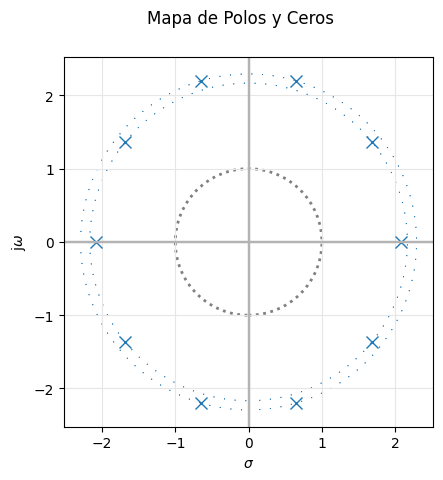

In [25]:
#Busco los polos del cuadrado del módulo de mi filtro Cheby

epss = 0.0965

num = [0, -(1/epss*256)]
den = [1, 0, 5/2, 0, 35/16, 0, 25/32, 0, 25/256, 0,  -(1/epss*256)]

H = sig.TransferFunction(num, den)

pzmap(H)

plt.show

np.roots(den)


Me quedo con los polos del lado de los $\sigma$ negativos y obtengo polos en:

$ s = -2,086 $

$ s = -1,6876 \pm j \ 1,3597 $

$ s = -0,6446 \pm j \ 2,200 $

De esta forma puedo armar mi transferencia de filtro Cheby:

$$ T(s) = \frac{2.086}{s + 2.086} \ \frac{4.6967}{s^{2} + s \ 3.3752 + 4.6967} \ \frac{5.2555}{s^{2} + s \ 1.2892 + 5.2555} $$


In [26]:
s = sp.symbols("s", real = True, posistive = True) 

H1 = (2.086) / (s + 2.086)

H2 = (4.6967) / (s**2 + s * 3.3752 + 4.6967)

H3 = (5.2555) / (s**2 + s * 1.12892 + 5.2555)

T = H1 * H2 * H3

Ts = sp.expand(T)

print_latex(a_equal_b_latex_s('T(s)', Ts)) # imprimo el resultado en LaTeX

<IPython.core.display.Math object>

Solo queda ver si los polos de este filtro coinciden con los de la plantilla:

array([-0.56446+2.22191019j, -0.56446-2.22191019j, -2.086  +0.j        ,
       -1.6876 +1.35967137j, -1.6876 -1.35967137j])

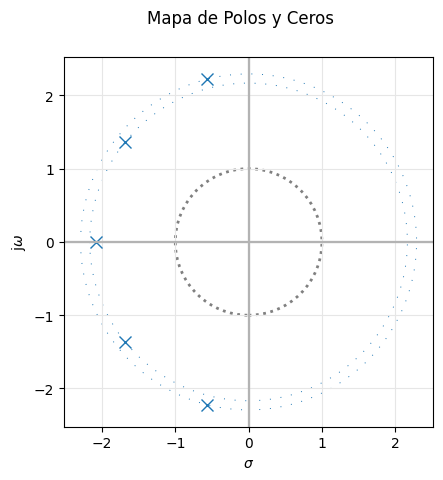

In [27]:
#Busco los polos del cuadrado del módulo de mi filtro Cheby (voy a usar todos los decimales para verificar con maxima precision)

num = [51.4897952891]
den = [1, 6.59012, 23.158125104, 51.749201379424, 72.746119524104, 51.4897952891]

H = sig.TransferFunction(num, den)

pzmap(H)

plt.show

np.roots(den)

### Conclusión: Los polos coinciden con lo proyectado salvo en uno en el cual la parte real me dio un 14% mas chica. Creo que puede deverse a que no utilicé la misma cantidad de decimales que en el resto de polos y perdí presición en el resultado. Pero en lineas generales cumple con lo establecido por la plantilla

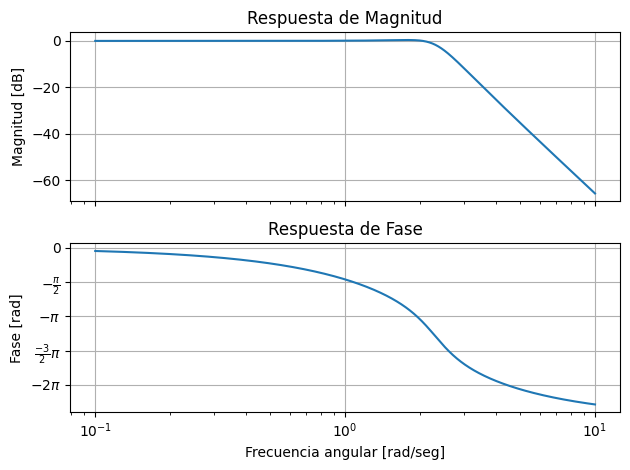

In [28]:
#Simulación de transferencia

num = [51.4897952891]
den = [1, 6.59012, 23.158125104, 51.749201379424, 72.746119524104, 51.4897952891]

f0 = 1

H = sig.TransferFunction(num, den)

# _ = analyze_sys([H]), probé esta función para ver el tema del retardo de grupo que vimos la última clase.

_, axes_hdl = bodePlot(H)

plt.tight_layout()
plt.show()

Desarrollo hecho por mí en papel:

<img src="./cheby1.png" align="center" width=800 />

<img src="./cheby2.png" align="center" width=800 />

## Items Bonus

Vamos a buscar los valores normalizados de la red del primer inciso, cuya transferencia era:

$$ \frac{\frac{1}{ C^{2} R_1 R_3 }}{s^2 + s \ \frac{1}{ C R_2} + \frac{1}{C^{2} R_{3}^{2}} } $$

Voy a elegir como norma de impedancia $R_3$ y como norma de frecuencia la propia frecuencia de corte:

$ \Omega_z  = \frac{1}{R_3}$

$\Omega_\omega = \frac{1}{C^{2} R_{3}^{2}}$

Por lo que la transferencia queda:

$$ \frac{k}{s^2 + s \ \frac{1}{Q} + 1 } = \frac{\frac{1}{R_1}}{s^2 + s \ \frac{1}{R_2} + 1 } $$


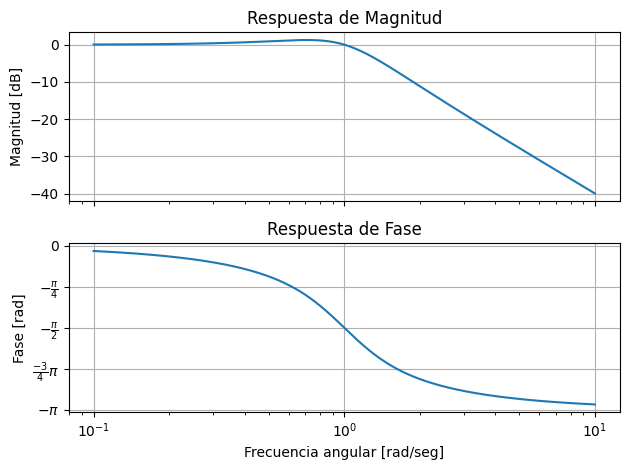

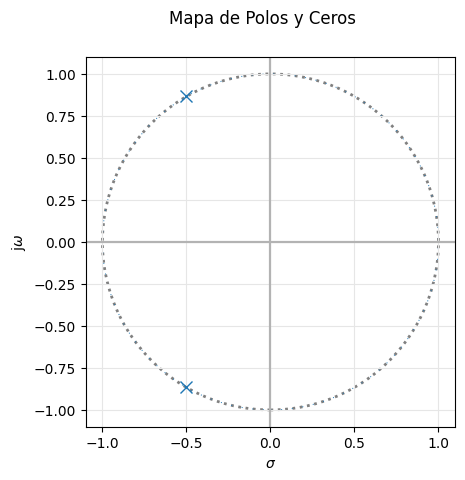

In [41]:
#Simulación de transferencia

R1 = 1
R2 = 1

num = [1/R1]
den = [1, 1/R2, 1]

H = sig.TransferFunction(num, den)

# _ = analyze_sys([H]), probé esta función para ver el tema del retardo de grupo que vimos la última clase.

_, axes_hdl = bodePlot(H)

plt.tight_layout()
pzmap(H)
plt.show()

**Nota:** Variando $R_2$ puedo variar el Q y así obtener sistemas con distinta amortiguación en la frecuencia de corte del filtro. Y con $R_1$ varío la ganancia en la banda de paso del filtro.